# Inference: Combined Light Curve & Radial Velocity

This notebook fits the light curve and radial-velocity time series **jointly**, via `make_lc_and_rv`, using one shared parameter set.

> **Note:** This notebook needs the `examples` dependency group (Python 3.11–3.13). From the repository root, run `./setup_env.sh --examples` and select the `.venv` environment as the Jupyter kernel.

In [1]:
# Running this notebook on Google Colab? Colab doesn't have this repository
# checked out, so sajax and its example dependencies aren't installed --
# run this cell first. (Not needed locally, on Binder, or in the built
# docs -- sajax is already installed there.)
import sys

if "google.colab" in sys.modules:
    import urllib.request

    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/SamMerc/sajax/main/binder/requirements.txt",
        "requirements.txt",
    )
    # -e . installs from a local checkout, which Colab doesn't have --
    # install the package itself from GitHub instead, then everything
    # else from the same requirements Binder uses (single source of
    # truth, see docs/conf.py and binder/requirements.txt).
    with open("requirements.txt") as f:
        lines = [line for line in f if not line.startswith("-e .")]
    with open("requirements.txt", "w") as f:
        f.writelines(lines)

    import subprocess
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "sajax @ git+https://github.com/SamMerc/sajax.git@main",
        "-r", "requirements.txt",
    ])

## Imports and Setup

In [2]:
import warnings
import os
import numpyro
# For multi-core parallelism (useful when running multiple MCMC chains in parallel)
numpyro.set_host_device_count(2)

# For CPU (use "gpu" for GPU)
numpyro.set_platform("cpu")

import numpy as np
import matplotlib.pyplot as plt
import jax

# arviz still prints its multi-release migration-guide FutureWarning on
# every import -- not something we control, so silence just that message.
warnings.filterwarnings("ignore", message="ArviZ is undergoing a major refactor", category=FutureWarning)
import arviz as az
import jax.numpy as jnp
import numpyro.distributions as dist
import numpyro_ext.distributions as ext_dist
import numpyro_ext.optim as optimx
import tempfile
from speclib import Spectrum

# silencing exotic-ld warning
warnings.filterwarnings("ignore", message="pkg_resources is deprecated", category=UserWarning)
from exotic_ld import StellarLimbDarkening
from matplotlib.animation import FuncAnimation, PillowWriter
import corner
from sajax.core import build_system, make_lc_and_rv
from IPython.display import Image, display
import astropy.units as u

# Set random seed for reproducibility
np.random.seed(42)

## Ground Truth: A Transiting Planet Across a Spotted Star (Light Curve + Radial Velocity)

In [3]:
# ---- Ground truth ----------
AR_LAT_TRUE, AR_LONG_TRUE = 5.0, 20.0     # spot latitude/longitude [deg]
AR_SIZE_TRUE              = 8.0           # spot angular radius [deg]
AR_SMOOTH_TRUE            = 3.0           # spot super-Gaussian order (see Introduction notebook)

P_ROT_TRUE                = 5.0           # stellar rotation period [days]
INC_STAR_TRUE             = 80.0          # stellar inclination [deg]

T0_TRUE, PERIOD_TRUE      = 0.0, 4.2      # mid-transit epoch, orbital period [days]
A_OVER_RSTAR_TRUE         = 15.0          # semi-major axis / R*
INCLINATION_TRUE          = np.pi / 2.0   # orbital inclination [rad]
ECC_TRUE, OMEGA_TRUE      = 0.0, 0.0      # circular orbit
K_TRUE                    = 0.1           # Rp/R*

RSTAR_TRUE   = 1.0  # stellar radius [R_sun]
STELLAR_GRID = 101  # stellar radius in pixels - high resolution for plotting
VE           = 2.0  # equatorial rotational velocity [km/s]
SOFTNESS = 1.0 / (10.0 * STELLAR_GRID)   # sigmoid transition width for the planet's soft occultation mask

# make_lc_and_rv derives the Keplerian reflex-RV semi-amplitude from a
# planet mass and a stellar mass.
PLANET_MASS_TRUE  = 1.0   # M_Jup
STELLAR_MASS_TRUE = 1.0   # M_sun
GAMMA_TRUE        = 0.0   # km/s -- systemic RV offset

# Effective temperature, logg, and metallicity for the quiet photosphere and spot
T_quiet, logg_quiet, metal_quiet    = 3700, 4.5, 0.2
T_active, logg_active, metal_active = 3000, 4.5, 0.2
stellar_model = 'phoenix'
# Stellar model grid and wavelength grid
NWAVE           = 10
wave_bounds     = [6_000, 25_000]                        # Angstrom
wavelength_grid = np.linspace(wave_bounds[0], wave_bounds[1], NWAVE) * u.AA
instrument_mode = 'JWST_NIRSpec_Prism'

# The PHOENIX data downloaded from speclib can either be downloaded or reloaded from the .gz file stored in the repo
import gzip, shutil
from pathlib import Path
from speclib import utils as speclib_utils

_bundled_dir = Path("speclib_data") / "phoenix"
_cache_dir = speclib_utils.get_library_root() / "phoenix"
_cache_dir.mkdir(parents=True, exist_ok=True)
for _gz_path in sorted(_bundled_dir.glob("*.fits.gz")):
    _dest_path = _cache_dir / _gz_path.stem  # strip ".gz"
    if not _dest_path.exists():
        with gzip.open(_gz_path, "rb") as _src, open(_dest_path, "wb") as _dst:
            shutil.copyfileobj(_src, _dst)

# Spectra (from speclib)
spec_quiet_obj  = Spectrum.from_grid(feh=metal_quiet,  teff=T_quiet,  logg=logg_quiet,
                                      model_grid=stellar_model, wavelength=wavelength_grid)
spec_active_obj = Spectrum.from_grid(feh=metal_active, teff=T_active, logg=logg_active,
                                      model_grid=stellar_model, wavelength=wavelength_grid)
wavelength  = spec_quiet_obj.wavelength.value    # (nwave,) Angstrom
spec_quiet  = spec_quiet_obj.flux.value          # (nwave,) quiet-photosphere flux
spec_active = spec_active_obj.flux.value         # (nwave,) spot flux

# Retrieve the limb-darkening coefficients from exotic-ld
# Similarly to speclib, the exotic-ld data is either downloaded directly or reloaded from the .gz file stored in the repo
_bundled_ld_dir = Path("exotic_ld_data_bundled")
_ld_data_dir = Path("exotic_ld_data")
for _gz_path in sorted(_bundled_ld_dir.rglob("*.gz")):
    _rel_path = _gz_path.relative_to(_bundled_ld_dir).with_suffix("")  # strip ".gz"
    _dest_path = _ld_data_dir / _rel_path
    if not _dest_path.exists():
        _dest_path.parent.mkdir(parents=True, exist_ok=True)
        with gzip.open(_gz_path, "rb") as _src, open(_dest_path, "wb") as _dst:
            shutil.copyfileobj(_src, _dst)

sld = StellarLimbDarkening(metal_quiet, T_quiet, logg_quiet, stellar_model)

# One representative wavelength
central_wave_idx  = int(len(wavelength) / 2)
central_wave      = wavelength[central_wave_idx]
flux_quiet_white  = spec_quiet[central_wave_idx]
flux_active_white = spec_active[central_wave_idx]
contrast_white    = flux_active_white / flux_quiet_white

wave_bin = np.array([central_wave - 500.0, central_wave + 500.0])
u1_white, u2_white = sld.compute_quadratic_ld_coeffs(wave_bin, instrument_mode)

# Transit duration
# Impact parameter (eccentricity-corrected)
b = (
    (A_OVER_RSTAR_TRUE * jnp.cos(INCLINATION_TRUE)) / RSTAR_TRUE
    * (1 - ECC_TRUE**2) / (1 + ECC_TRUE * jnp.sin(OMEGA_TRUE))
)
# Argument inside arcsin
arg = (
    (1/A_OVER_RSTAR_TRUE)
    * jnp.sqrt((1 + K_TRUE)**2 - b**2)
    / jnp.sin(INCLINATION_TRUE)
)
# Numerical safety
arg = np.clip(arg, -1.0, 1.0)
# Transit duration
T_dur = (
    (PERIOD_TRUE / jnp.pi)
    * jnp.sqrt(1 - ECC_TRUE**2) / (1 + ECC_TRUE * jnp.sin(OMEGA_TRUE))
    * jnp.arcsin(arg)
)
# Time array: +/-3x the transit duration
times = jnp.linspace(-3.0 * T_dur, 3.0 * T_dur, 600)

In [4]:
# ---- Build the model once -- reused both for the ground truth below and for the fit later ----
combined_model = build_system(
    wavelength        = central_wave,
    flux_quiet        = 1.0,
    ld_coeffs         = [u1_white, u2_white],
    inc_star          = INC_STAR_TRUE,
    times             = times,
    P_rot             = P_ROT_TRUE,
    t0                = T0_TRUE,
    period            = PERIOD_TRUE,
    a_over_rstar      = A_OVER_RSTAR_TRUE,
    inclination       = INCLINATION_TRUE,
    k                 = K_TRUE,
    ecc               = ECC_TRUE,
    omega_peri        = OMEGA_TRUE,
    stellar_grid_size = STELLAR_GRID,
    ve                = VE,
    ld_mode           = "quadratic",
    oversample        = 2,
)

# ---- Generate the true light curve + radial-velocity curve, from one shared computation ----
result_true = make_lc_and_rv(
    combined_model,
    flux_active      = contrast_white,
    ar_lat           = AR_LAT_TRUE,
    ar_long          = AR_LONG_TRUE,
    ar_size          = AR_SIZE_TRUE,
    ar_smoothness    = AR_SMOOTH_TRUE,
    planet_mass      = PLANET_MASS_TRUE,
    stellar_mass     = STELLAR_MASS_TRUE,
    gamma            = GAMMA_TRUE,
    transit_softness = SOFTNESS,
)
lc_true    = jnp.asarray(result_true[0]) / jnp.max(result_true[0])
rv_true    = jnp.asarray(result_true[1]) * 1000.0   # km/s -> m/s
star_maps  = jnp.asarray(result_true[2]) / jnp.max(result_true[2])   # flux map -- shared by lc and rv
vmin, vmax = float(star_maps.min()), float(star_maps.max())

# ---- Add noise ----
SIGMA_LC = 300e-6   # 300 ppm photon noise
SIGMA_RV = 2.0      # m/s -- representative of a high-precision RV spectrograph
np.random.seed(0)

lc_obs = lc_true + np.random.normal(0.0, SIGMA_LC, size=lc_true.shape)
lc_err = SIGMA_LC * jnp.ones(lc_obs.shape, dtype=float)

rv_obs = rv_true + np.random.normal(0.0, SIGMA_RV, size=rv_true.shape)
rv_err = SIGMA_RV * jnp.ones(rv_obs.shape, dtype=float)

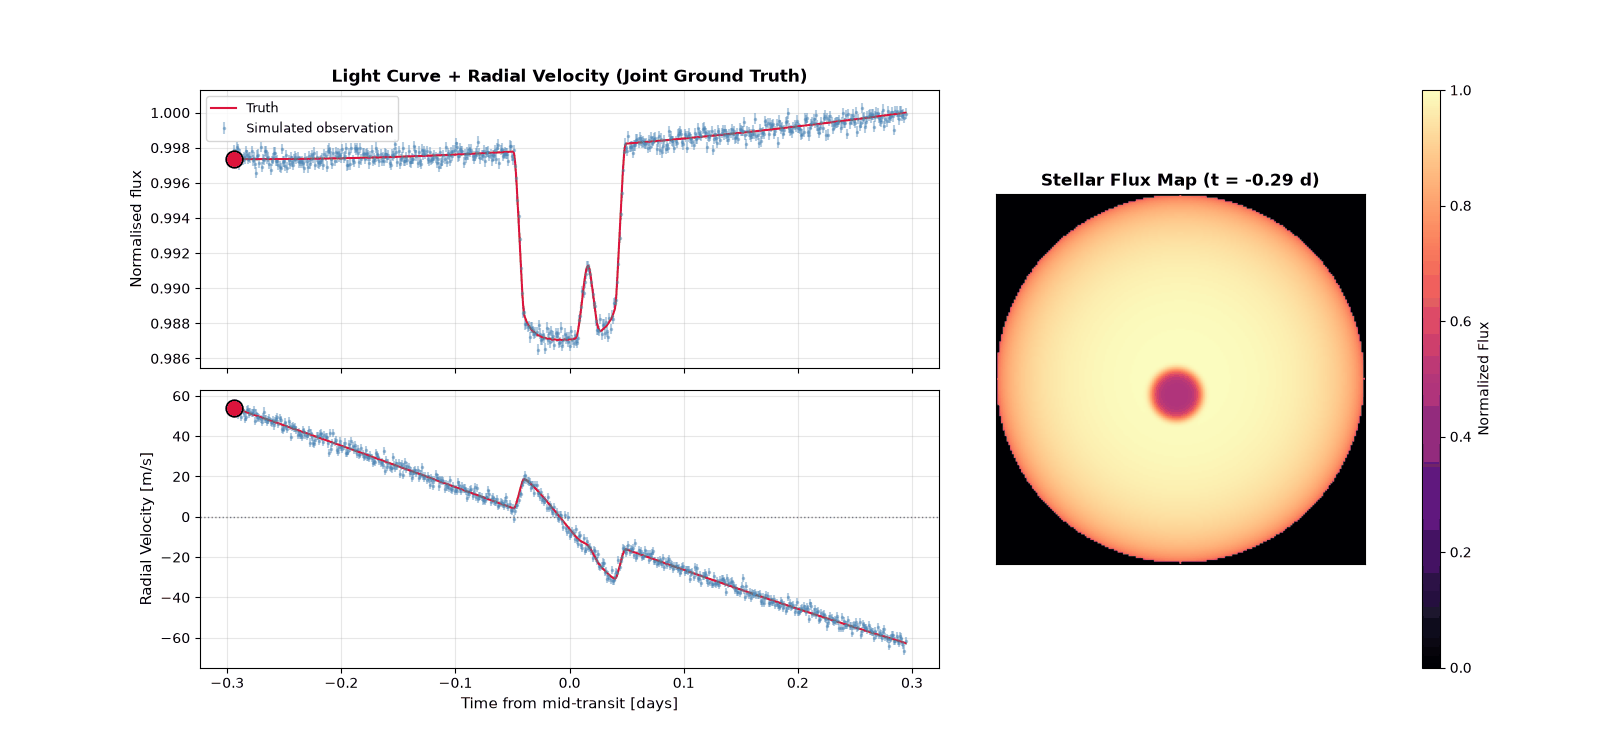

In [5]:
# ---- Plot: light curve + radial-velocity curve + rotating/transiting stellar map ----
fig, axes = plt.subplot_mosaic(
    [['LC', 'MAP', 'cbar'],
     ['RV', 'MAP', 'cbar']],
    figsize=(16, 7.5), height_ratios=[1, 1], width_ratios=[2, 1, 0.05],
    gridspec_kw={'hspace': 0.08, 'wspace': 0.15},
)

axes['LC'].errorbar(times, lc_obs, yerr=lc_err, fmt='.', ms=3, color='steelblue', alpha=0.4, label='Simulated observation')
axes['LC'].plot(times, lc_true, '-', color='crimson', lw=1.5, label='Truth')
lc_marker, = axes['LC'].plot([times[0]], [lc_true[0]], 'o', markersize=12, color='crimson',
                              markeredgecolor='black', markeredgewidth=1.2, zorder=5)
axes['LC'].set_ylabel('Normalised flux', fontsize=11)
axes['LC'].set_title('Light Curve + Radial Velocity (Joint Ground Truth)', fontsize=12, fontweight='bold')
axes['LC'].legend(fontsize=9); axes['LC'].grid(alpha=0.3)
axes['LC'].tick_params(labelbottom=False)
axes['LC'].sharex(axes['RV'])

axes['RV'].errorbar(times, rv_obs, yerr=rv_err, fmt='.', ms=3, color='steelblue', alpha=0.4, label='Simulated observation')
axes['RV'].plot(times, rv_true, '-', color='crimson', lw=1.5, label='Truth')
axes['RV'].axhline(0.0, color='gray', linewidth=1, linestyle=':')
rv_marker, = axes['RV'].plot([times[0]], [rv_true[0]], 'o', markersize=12, color='crimson',
                              markeredgecolor='black', markeredgewidth=1.2, zorder=5)
axes['RV'].set_xlabel('Time from mid-transit [days]', fontsize=11)
axes['RV'].set_ylabel('Radial Velocity [m/s]', fontsize=11)
axes['RV'].grid(alpha=0.3)

im = axes['MAP'].imshow(star_maps[0], cmap='magma', origin='lower', vmin=vmin, vmax=vmax)
map_title = axes['MAP'].set_title(f'Stellar Flux Map (t = {times[0]:+.2f} d)', fontsize=12, fontweight='bold')
axes['MAP'].set_xticks([]); axes['MAP'].set_yticks([])
fig.colorbar(im, cax=axes['cbar'], label='Normalized Flux')

def _update(frame):
    lc_marker.set_data([times[frame]], [lc_true[frame]])
    rv_marker.set_data([times[frame]], [rv_true[frame]])
    im.set_data(star_maps[frame])
    map_title.set_text(f'Stellar Flux Map (t = {times[frame]:+.2f} d)')
    return lc_marker, rv_marker, im, map_title

frame_idx = list(range(0, len(times), 4))
anim = FuncAnimation(fig, _update, frames=frame_idx, interval=80, blit=False)

with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as _tmp:
    gif_path = _tmp.name
anim.save(gif_path, writer=PillowWriter(fps=15))
plt.close(fig)
with open(gif_path, 'rb') as f:
    gif_bytes = f.read()
os.remove(gif_path)

display(Image(data=gif_bytes, format='gif'))

## Fitting Method
The inference below can be done two ways:

* **`"map"`** (default) - a fast maximum a posteriori (MAP) point estimate found via gradient-based optimization (`numpyro_ext.optim`, using `jaxopt`'s L-BFGS under the hood). As this takes only a few seconds-minutes, it keeps the notebook quick to run end-to-end.
  
* **`"nuts"`** - the full posterior via NUTS MCMC, giving real uncertainties and the corner/trace plots below, at the cost of much longer runtime (on the order of hours for the current setup). See the "Runtime tuning" cell further down to learn about the key `SAJAX` knobs to turn to speed this up.

Switch `FIT_METHOD` and re-run from here on to change which one is used.

In [6]:
FIT_METHOD = "map"   # "map" or "nuts"
assert FIT_METHOD in ("map", "nuts")

## Joint Fit: Spot, Orbit, and Planet Mass from the Light Curve + Radial Velocity

One shared parameter set drives both `make_lc_and_rv` outputs, and both get their own Gaussian likelihood so that the two datasets jointly constrain the fit.

In [7]:
# Define the joint forward model for the light curve + radial-velocity curve
def model_combined(lc_yerr, rv_yerr, lc_y=None, rv_y=None):

    # Priors for the parameters we're fitting for
    # Active region latitude
    sin_ar_lat = numpyro.sample("sin_ar_lat", dist.Uniform(-1., 1.))

    # Active region longitude
    ar_long = numpyro.sample("ar_long", dist.Uniform(-180., 180.))

    # Active region size
    ar_size = numpyro.sample("ar_size", dist.Uniform(5., 45.))

    # Active region contrast
    ar_contrast = numpyro.sample("ar_contrast", dist.Uniform(0., 2.))

    # Orbital period
    period = numpyro.sample("period", dist.Normal(PERIOD_TRUE, 0.0005))

    # Semi-major axis
    a_over_rstar = numpyro.sample("a_over_rstar", dist.Uniform(0., 50.))

    # Inclination
    inclination = numpyro.sample("inclination", dist.Uniform(jnp.deg2rad(70.), jnp.deg2rad(110.)))

    # Planet-to-star radius ratio
    k = numpyro.sample("k", dist.Uniform(0., 1.))

    # Limb-darkening coefficients
    u = numpyro.sample("u", ext_dist.QuadLDParams())

    # Planet mass -- the new parameter only a joint LC+RV fit can pin down
    planet_mass = numpyro.sample("planet_mass", dist.Uniform(0., 5.))

    # Systemic RV offset (nuisance parameter, as in any real RV fit)
    gamma = numpyro.sample("gamma", dist.Normal(0.0, 0.1))

    # Light curve + radial-velocity curve, from one shared computation
    lc_pred, rv_pred = make_lc_and_rv(
        combined_model,
        flux_active      = ar_contrast,
        ld_coeffs_quiet  = jnp.asarray([u]),
        ar_lat           = jnp.rad2deg(jnp.arcsin(sin_ar_lat)),
        ar_long          = ar_long,
        ar_size          = ar_size,
        ar_smoothness    = AR_SMOOTH_TRUE,
        period           = period,
        a_over_rstar     = a_over_rstar,
        inclination      = inclination,
        k                = k,
        t0               = T0_TRUE,
        transit_softness = SOFTNESS,
        planet_mass      = planet_mass,
        stellar_mass     = STELLAR_MASS_TRUE,
        gamma            = gamma,
    )[:2]
    lc_pred = lc_pred / jnp.max(lc_pred)   # Normalise to unity
    rv_pred = rv_pred * 1000.0             # km/s -> m/s

    # Track both curves
    numpyro.deterministic("light_curve", lc_pred)
    numpyro.deterministic("rv_curve", rv_pred)

    # Two independent Gaussian likelihoods, one per dataset, sharing every parameter above
    numpyro.sample("obs_lc", dist.Normal(lc_pred, lc_yerr), obs=lc_y)
    numpyro.sample("obs_rv", dist.Normal(rv_pred, rv_yerr), obs=rv_y)

# Bounds from which to sample the initial position
INIT_POSITIONS_BOUNDS = {
    "sin_ar_lat":    [jnp.sin(jnp.deg2rad(AR_LAT_TRUE - 10.)), jnp.sin(jnp.deg2rad(AR_LAT_TRUE + 10.))],
    "ar_long":       [AR_LONG_TRUE - 10., AR_LONG_TRUE + 10.],
    "ar_size":       [jnp.maximum(AR_SIZE_TRUE - 5., 0.), AR_SIZE_TRUE + 5.],
    "ar_contrast":   [jnp.maximum(contrast_white - 0.2, 0.), contrast_white + 0.2],
    "period":        [PERIOD_TRUE - 0.0005, PERIOD_TRUE + 0.0005],
    "a_over_rstar":  [A_OVER_RSTAR_TRUE - 2., A_OVER_RSTAR_TRUE + 2.],
    "inclination":   [INCLINATION_TRUE - jnp.deg2rad(5.), INCLINATION_TRUE + jnp.deg2rad(5.)],
    "k":             [jnp.maximum(K_TRUE - 0.03, 0.), K_TRUE + 0.03],
    "planet_mass":   [jnp.maximum(PLANET_MASS_TRUE - 0.3, 0.), PLANET_MASS_TRUE + 0.3],
    "gamma":         [GAMMA_TRUE - 0.01, GAMMA_TRUE + 0.01],
}
# Initial positions
init_pos_key = jax.random.PRNGKey(12)
init_pos = {
    name: jax.random.uniform(init_pos_key, minval=lo, maxval=hi)
    for name, (lo, hi) in INIT_POSITIONS_BOUNDS.items()
}
init_pos["u"] = jnp.array([u1_white + 0.2, u2_white - 0.2])

if FIT_METHOD == "nuts":
    # Full posterior via NUTS MCMC
    sampler_combined = numpyro.infer.MCMC(
        numpyro.infer.NUTS(
            model_combined,
            dense_mass=True,
            regularize_mass_matrix=True,
            init_strategy=numpyro.infer.init_to_value(values=init_pos),
        ),
        num_warmup=100,
        num_samples=400,
        num_chains=2,
        progress_bar=True,
    )
    sampler_combined.run(jax.random.PRNGKey(0), jnp.asarray(lc_err), jnp.asarray(rv_err),
                         lc_y=jnp.asarray(lc_obs), rv_y=jnp.asarray(rv_obs),
                         extra_fields=("potential_energy",))
else:
    # MAP point estimate via gradient-based optimization: first the
    # transit/orbit geometry, then a joint refinement including
    # ar_contrast/u/planet_mass/gamma (mirrors inference_lc.ipynb's
    # two-stage pattern).
    run_geom = optimx.optimize(
        model_combined,
        sites=["sin_ar_lat", "ar_long", "ar_size", "period", "a_over_rstar",
               "inclination", "k"],
        start=init_pos,
    )
    soln_geom = run_geom(jax.random.PRNGKey(0), jnp.asarray(lc_err), jnp.asarray(rv_err),
                          lc_y=jnp.asarray(lc_obs), rv_y=jnp.asarray(rv_obs))

    run_joint = optimx.optimize(model_combined, start={name: soln_geom[name] for name in init_pos})
    soln_combined = run_joint(jax.random.PRNGKey(1), jnp.asarray(lc_err), jnp.asarray(rv_err),
                               lc_y=jnp.asarray(lc_obs), rv_y=jnp.asarray(rv_obs))

## Summary and Traces

In [8]:
if FIT_METHOD == "nuts":
    # Formatting samples
    inf_data = az.from_numpyro(sampler_combined)
    inf_data.posterior["ar_lat"] = np.rad2deg(np.arcsin(inf_data.posterior["sin_ar_lat"].clip(-1.0, 1.0)))
    inf_data.posterior["inclination"] = np.rad2deg(inf_data.posterior["inclination"])
    inf_data.posterior["u1"] = inf_data.posterior["u"].isel(u_dim_0=0)
    inf_data.posterior["u2"] = inf_data.posterior["u"].isel(u_dim_0=1)

    # Making nice display names for the parameters in the corner plot and ArviZ summary
    display_names = {
        "ar_lat": r"$\phi_{\rm ar}$ [deg]", "ar_long": r"$\lambda_{\rm ar}$ [deg]",
        "ar_size": r"$r_{\rm ar}$ [deg]", "ar_contrast": r"$C_{\rm ar}$",
        "period": r"$P$ [days]", "a_over_rstar": r"$a/R_{\star}$",
        "inclination": r"$i$ [deg]", "k": r"$R_p/R_{\star}$",
        "u1": r"$u_1$", "u2": r"$u_2$",
        "planet_mass": r"$M_p$ [$M_{\rm Jup}$]", "gamma": r"$\gamma$ [km/s]",
    }
    inf_data.posterior = inf_data.posterior[list(display_names)].rename(display_names)
    param_names = list(display_names.values())

    # Showing summary
    sampler_combined.print_summary()

    # Plotting traces
    _ = az.plot_trace(
        inf_data,
        var_names=param_names,
        backend_kwargs={"constrained_layout": True},
    )
else:
    # MAP: no posterior to summarize/trace over -- report the point
    # estimate against the ground truth for each fitted parameter instead.
    map_summary = {
        "ar_lat [deg]":      (float(jnp.rad2deg(jnp.arcsin(soln_combined["sin_ar_lat"]))), AR_LAT_TRUE),
        "ar_long [deg]":     (float(soln_combined["ar_long"]), AR_LONG_TRUE),
        "ar_size [deg]":     (float(soln_combined["ar_size"]), AR_SIZE_TRUE),
        "ar_contrast":       (float(soln_combined["ar_contrast"]), float(contrast_white)),
        "period [days]":     (float(soln_combined["period"]), PERIOD_TRUE),
        "a_over_rstar":      (float(soln_combined["a_over_rstar"]), A_OVER_RSTAR_TRUE),
        "inclination [deg]": (float(jnp.rad2deg(soln_combined["inclination"])), float(np.rad2deg(INCLINATION_TRUE))),
        "k":                 (float(soln_combined["k"]), float(K_TRUE)),
        "u1":                (float(soln_combined["u"][0]), float(u1_white)),
        "u2":                (float(soln_combined["u"][1]), float(u2_white)),
        "planet_mass [Mjup]": (float(soln_combined["planet_mass"]), PLANET_MASS_TRUE),
        "gamma [km/s]":      (float(soln_combined["gamma"]), GAMMA_TRUE),
    }
    print(f"{'parameter':<20s}{'MAP':>12s}{'truth':>12s}")
    for name, (map_val, truth_val) in map_summary.items():
        print(f"{name:<20s}{map_val:>12.4f}{truth_val:>12.4f}")

    # Fit quality check for both datasets independently
    lc_map_pred = jnp.asarray(soln_combined["light_curve"])
    rv_map_pred = jnp.asarray(soln_combined["rv_curve"])
    chi2_lc = float(jnp.sum(((jnp.asarray(lc_obs) - lc_map_pred) / SIGMA_LC) ** 2))
    chi2_rv = float(jnp.sum(((jnp.asarray(rv_obs) - rv_map_pred) / SIGMA_RV) ** 2))
    print(f"\nchi^2 (light curve): {chi2_lc:.1f}  ({len(lc_obs)} points)")
    print(f"chi^2 (radial velocity): {chi2_rv:.1f}  ({len(rv_obs)} points)")

parameter                    MAP       truth
ar_lat [deg]              4.8794      5.0000
ar_long [deg]            19.9005     20.0000
ar_size [deg]             7.4887      8.0000
ar_contrast               0.3855      0.4854
period [days]             4.2000      4.2000
a_over_rstar             14.9898     15.0000
inclination [deg]        89.9610     90.0000
k                         0.1000      0.1000
u1                        0.0204      0.0967
u2                        0.3595      0.2662
planet_mass [Mjup]        0.9886      1.0000
gamma [km/s]              0.0003      0.0000

chi^2 (light curve): 597.4  (600 points)
chi^2 (radial velocity): 537.3  (600 points)


## Corner Plot and Best-fit Light Curve + Radial Velocity

With `FIT_METHOD = "nuts"`, this shows the full posterior corner plot (with truth/posterior-median/MAP marked on every panel), followed by the best-fit light curve, radial velocity curve, residuals, and a rotating stellar-flux-map animation at the posterior-median (and MAP) parameters.

With `FIT_METHOD = "map"`, the corner plot is skipped -- there's no distribution to show, just a single point estimate -- straight to the best-fit light curve, radial velocity curve, residuals, and star-map animation at the MAP parameters.

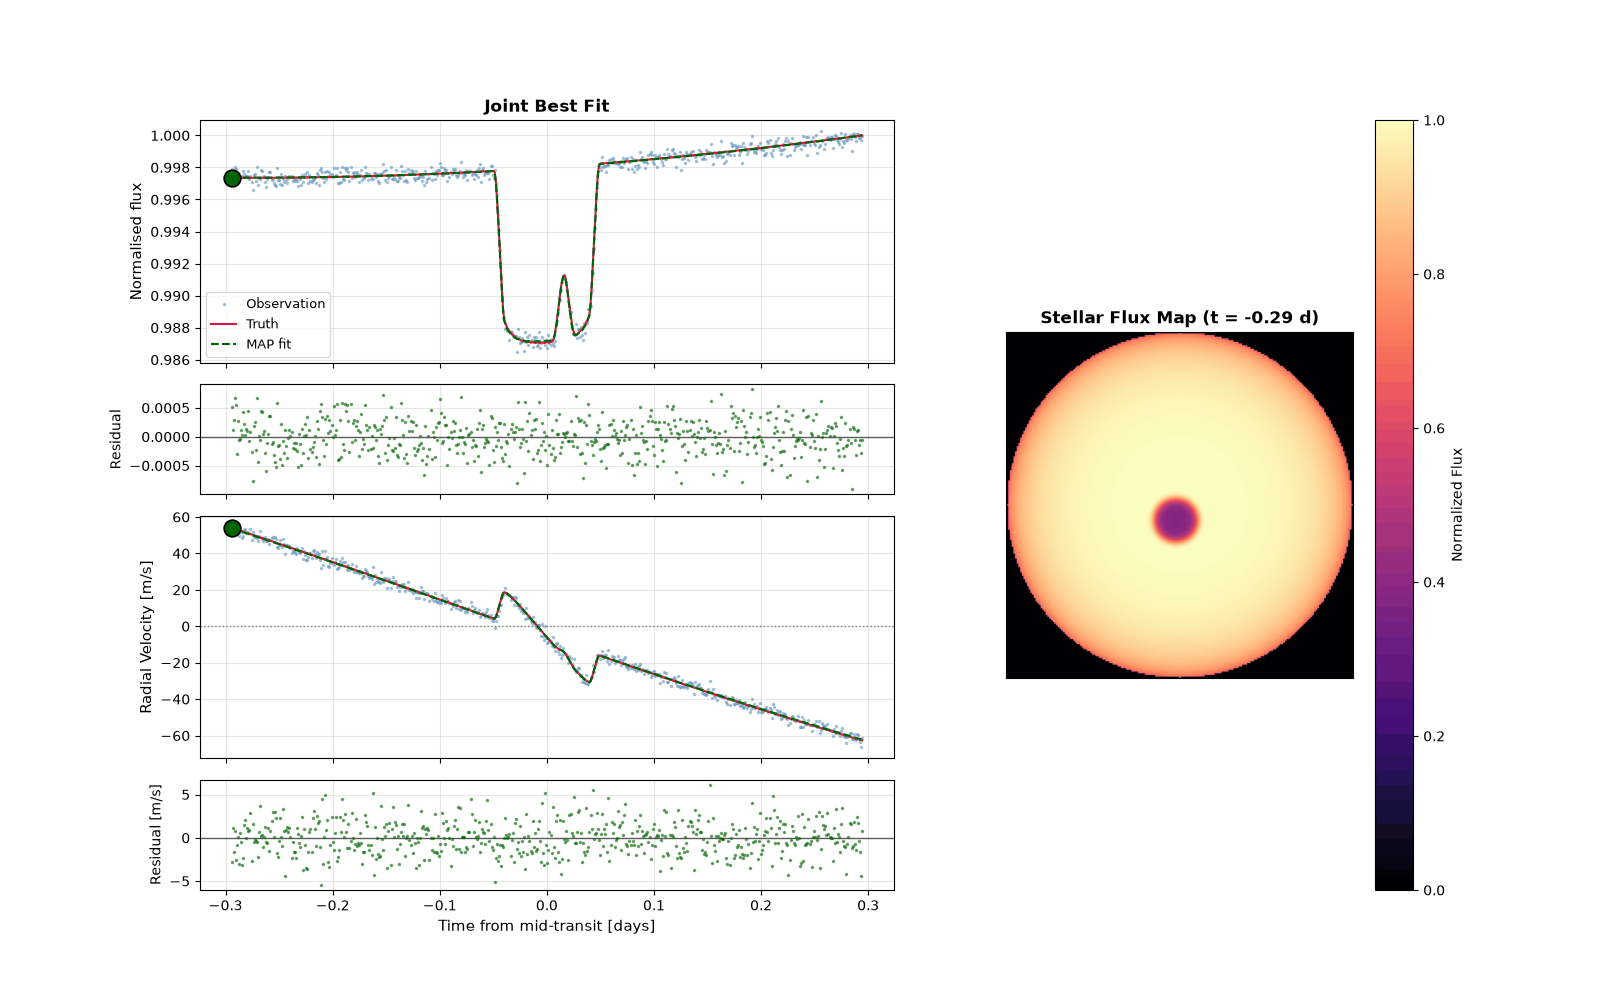

In [9]:
if FIT_METHOD == "nuts":
    # Build a dictionary for the true parameter values
    truths_combined = dict(
        ar_lat=AR_LAT_TRUE, ar_long=AR_LONG_TRUE, ar_size=AR_SIZE_TRUE,
        ar_contrast=contrast_white, period=PERIOD_TRUE, a_over_rstar=A_OVER_RSTAR_TRUE,
        inclination=np.rad2deg(INCLINATION_TRUE), k=K_TRUE, u=jnp.array([u1_white, u2_white]),
        planet_mass=PLANET_MASS_TRUE, gamma=GAMMA_TRUE,
    )

    # Retrieve the samples, and MAP index from the sampler
    samples_combined = sampler_combined.get_samples()
    map_idx_combined = int(np.argmin(np.array(sampler_combined.get_extra_fields()["potential_energy"])))

    # ---- Corner plot with truth/median/MAP overlaid on every panel ----
    corner_samples = {
        "ar_lat":       np.rad2deg(np.arcsin(np.clip(np.array(samples_combined["sin_ar_lat"]), -1.0, 1.0))),
        "ar_long":      np.array(samples_combined["ar_long"]),
        "ar_size":      np.array(samples_combined["ar_size"]),
        "ar_contrast":  np.array(samples_combined["ar_contrast"]),
        "period":       np.array(samples_combined["period"]),
        "a_over_rstar": np.array(samples_combined["a_over_rstar"]),
        "inclination":  np.rad2deg(np.array(samples_combined["inclination"])),
        "k":            np.array(samples_combined["k"]),
        "planet_mass":  np.array(samples_combined["planet_mass"]),
        "gamma":        np.array(samples_combined["gamma"]),
    }
    corner_samples["u1"] = np.array(samples_combined["u"])[:, 0]
    corner_samples["u2"] = np.array(samples_combined["u"])[:, 1]
    corner_truths = {name: truths_combined[name] for name in corner_samples if name not in ("u1", "u2")}
    corner_truths["u1"] = u1_white
    corner_truths["u2"] = u2_white

    samples_arr = np.stack([corner_samples[name] for name in corner_samples.keys()], axis=-1)
    truths_arr  = [float(corner_truths[name]) for name in corner_samples.keys()]
    median_arr  = [float(np.median(corner_samples[name])) for name in corner_samples.keys()]
    map_arr     = [float(corner_samples[name][map_idx_combined]) for name in corner_samples.keys()]

    # Generate corner plot -- look for the planet_mass panels in
    # particular: this is the parameter neither inference_lc.ipynb (light
    # curve alone) nor inference_rv.ipynb (RV alone) could constrain.
    fig = corner.corner(
        samples_arr, labels=param_names, truths=truths_arr,
        show_titles=True, title_fmt='.4f',
        label_kwargs={'fontsize': 14}, title_kwargs={'fontsize': 11},
    )

    corner.overplot_lines(fig, median_arr, color='darkorange', linestyle='--', linewidth=1.2)
    corner.overplot_points(fig, [median_arr], marker='s', color='darkorange', markersize=6)
    corner.overplot_lines(fig, map_arr, color='mediumseagreen', linestyle='-.', linewidth=1.2)
    corner.overplot_points(fig, [map_arr], marker='D', color='mediumseagreen', markersize=6)

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color='#4682b4', label='Truth'),
        Line2D([0], [0], color='darkorange', linestyle='--', label='Posterior median'),
        Line2D([0], [0], color='mediumseagreen', linestyle='-.', label='MAP'),
    ]
    fig.legend(handles=legend_handles, loc='upper right', fontsize=14, bbox_to_anchor=(0.98, 0.98))
    plt.show()

    # Posterior-median and MAP light curves/RV curves + residuals
    lc_samples_all     = jnp.array(samples_combined["light_curve"])   # (num_samples, ntimes)
    rv_samples_all     = jnp.array(samples_combined["rv_curve"])
    lc_bestfit          = jnp.median(lc_samples_all, axis=0)
    rv_bestfit           = jnp.median(rv_samples_all, axis=0)
    lc_map               = lc_samples_all[map_idx_combined]
    rv_map                = rv_samples_all[map_idx_combined]
    residuals_lc_bestfit = jnp.array(lc_obs) - lc_bestfit
    residuals_rv_bestfit = jnp.array(rv_obs) - rv_bestfit
    residuals_lc_map     = jnp.array(lc_obs) - lc_map
    residuals_rv_map      = jnp.array(rv_obs) - rv_map

    # The point estimate handed to the best-fit map/curves below: posterior medians here
    median_combined = {name: float(jnp.median(arr)) for name, arr in samples_combined.items() if arr.ndim == 1}
    u1_median, u2_median = (float(x) for x in jnp.median(jnp.array(samples_combined["u"]), axis=0))
    median_combined["ar_lat"] = jnp.rad2deg(jnp.arcsin(median_combined["sin_ar_lat"]))
else:
    # MAP point estimate light curve/RV curve + residuals
    u1_median, u2_median = float(soln_combined["u"][0]), float(soln_combined["u"][1])
    median_combined = {
        "ar_lat":       float(jnp.rad2deg(jnp.arcsin(soln_combined["sin_ar_lat"]))),
        "ar_long":      float(soln_combined["ar_long"]),
        "ar_size":      float(soln_combined["ar_size"]),
        "ar_contrast":  float(soln_combined["ar_contrast"]),
        "period":       float(soln_combined["period"]),
        "a_over_rstar": float(soln_combined["a_over_rstar"]),
        "inclination":  float(soln_combined["inclination"]),
        "k":            float(soln_combined["k"]),
        "planet_mass":  float(soln_combined["planet_mass"]),
        "gamma":        float(soln_combined["gamma"]),
    }
    lc_bestfit            = jnp.array(soln_combined["light_curve"])   # (ntimes,) -- straight from the model
    rv_bestfit             = jnp.array(soln_combined["rv_curve"])
    residuals_lc_bestfit  = jnp.array(lc_obs) - lc_bestfit
    residuals_rv_bestfit   = jnp.array(rv_obs) - rv_bestfit

# ---- Best-fit stellar map + light curve + radial-velocity curve (shared by both fitting methods) ----
result_bestfit = make_lc_and_rv(
    combined_model,
    flux_active      = median_combined["ar_contrast"],
    ld_coeffs_quiet  = jnp.asarray([[u1_median, u2_median]]),
    ar_lat           = median_combined["ar_lat"],
    ar_long          = median_combined["ar_long"],
    ar_size          = median_combined["ar_size"],
    ar_smoothness    = AR_SMOOTH_TRUE,
    period           = max(median_combined["period"], 1e-3),
    a_over_rstar     = median_combined["a_over_rstar"],
    inclination      = median_combined["inclination"],
    k                = median_combined["k"],
    t0               = T0_TRUE,
    transit_softness = SOFTNESS,
    planet_mass      = median_combined["planet_mass"],
    stellar_mass     = STELLAR_MASS_TRUE,
    gamma            = median_combined["gamma"],
)
star_maps_bestfit = jnp.asarray(result_bestfit[2])
vmin_bf, vmax_bf  = float(star_maps_bestfit.min()), float(star_maps_bestfit.max())

# Plotting
fig, axes = plt.subplot_mosaic(
    [['LC', 'MAP'], ['LC_RESID', 'MAP'], ['RV', 'MAP'], ['RV_RESID', 'MAP']],
    figsize=(16, 10), height_ratios=[2.2, 1, 2.2, 1], width_ratios=[1.6, 1],
    gridspec_kw={'hspace': 0.12}, sharex=False,
)
ax_lc, ax_lc_resid, ax_rv, ax_rv_resid, ax_map = (
    axes['LC'], axes['LC_RESID'], axes['RV'], axes['RV_RESID'], axes['MAP']
)

# Light-curve panel
ax_lc.plot(times, lc_obs, '.', ms=3, color='steelblue', alpha=0.4, label='Observation')
ax_lc.plot(times, lc_true, '-', color='crimson', lw=1.5, label='Truth')
ax_lc.plot(times, lc_bestfit, '--', color='darkgreen', lw=1.5,
           label='Posterior-median fit' if FIT_METHOD == 'nuts' else 'MAP fit')
if FIT_METHOD == 'nuts':
    ax_lc.plot(times, lc_map, '-.', color='mediumseagreen', lw=1.5, label='MAP fit')
lc_marker, = ax_lc.plot([times[0]], [lc_bestfit[0]], 'o', markersize=12,
                         color='darkgreen', markeredgecolor='black', markeredgewidth=1.2, zorder=5)
ax_lc.set_ylabel('Normalised flux', fontsize=11)
ax_lc.set_title('Joint Best Fit', fontsize=12, fontweight='bold')
ax_lc.legend(fontsize=9); ax_lc.grid(alpha=0.3)
ax_lc.tick_params(labelbottom=False)
ax_lc.sharex(ax_lc_resid)

ax_lc_resid.axhline(0.0, color='black', lw=1.0, alpha=0.6)
ax_lc_resid.plot(times, residuals_lc_bestfit, '.', ms=3, color='darkgreen', alpha=0.5)
if FIT_METHOD == 'nuts':
    ax_lc_resid.plot(times, residuals_lc_map, '.', ms=3, color='mediumseagreen', alpha=0.5)
ax_lc_resid.set_ylabel('Residual', fontsize=10)
ax_lc_resid.grid(alpha=0.3)
ax_lc_resid.tick_params(labelbottom=False)
ax_lc_resid.sharex(ax_rv)

# Radial-velocity panel
ax_rv.plot(times, rv_obs, '.', ms=3, color='steelblue', alpha=0.4, label='Observation')
ax_rv.plot(times, rv_true, '-', color='crimson', lw=1.5, label='Truth')
ax_rv.plot(times, rv_bestfit, '--', color='darkgreen', lw=1.5,
           label='Posterior-median fit' if FIT_METHOD == 'nuts' else 'MAP fit')
if FIT_METHOD == 'nuts':
    ax_rv.plot(times, rv_map, '-.', color='mediumseagreen', lw=1.5, label='MAP fit')
ax_rv.axhline(0.0, color='gray', linewidth=1, linestyle=':')
rv_marker, = ax_rv.plot([times[0]], [rv_bestfit[0]], 'o', markersize=12,
                         color='darkgreen', markeredgecolor='black', markeredgewidth=1.2, zorder=5)
ax_rv.set_ylabel('Radial Velocity [m/s]', fontsize=11)
ax_rv.grid(alpha=0.3)
ax_rv.tick_params(labelbottom=False)
ax_rv.sharex(ax_rv_resid)

ax_rv_resid.axhline(0.0, color='black', lw=1.0, alpha=0.6)
ax_rv_resid.plot(times, residuals_rv_bestfit, '.', ms=3, color='darkgreen', alpha=0.5)
if FIT_METHOD == 'nuts':
    ax_rv_resid.plot(times, residuals_rv_map, '.', ms=3, color='mediumseagreen', alpha=0.5)
ax_rv_resid.set_xlabel('Time from mid-transit [days]', fontsize=11)
ax_rv_resid.set_ylabel('Residual [m/s]', fontsize=10)
ax_rv_resid.grid(alpha=0.3)

# Stellar surface map panel
im = ax_map.imshow(star_maps_bestfit[0], cmap='magma', origin='lower', vmin=vmin_bf, vmax=vmax_bf)
map_title = ax_map.set_title(f'Stellar Flux Map (t = {times[0]:+.2f} d)', fontsize=12, fontweight='bold')
ax_map.set_xticks([]); ax_map.set_yticks([])
plt.colorbar(im, ax=ax_map, label='Normalized Flux')

def _update(frame):
    lc_marker.set_data([times[frame]], [lc_bestfit[frame]])
    rv_marker.set_data([times[frame]], [rv_bestfit[frame]])
    im.set_data(star_maps_bestfit[frame])
    map_title.set_text(f'Stellar Flux Map (t = {times[frame]:+.2f} d)')
    return lc_marker, rv_marker, im, map_title
frame_idx = list(range(0, len(times), 4))
anim = FuncAnimation(fig, _update, frames=frame_idx, interval=80, blit=False)

with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as _tmp:
    gif_path = _tmp.name
anim.save(gif_path, writer=PillowWriter(fps=30))
plt.close(fig)
with open(gif_path, 'rb') as f:
    gif_bytes = f.read()
os.remove(gif_path)

display(Image(data=gif_bytes, format='gif'))